In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

df1 = pd.read_csv("COEBiddingResultsPrices_extended.csv", thousands=',')
df1.head()

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2002-04,1,Category A,1110,1092,2484,37201
1,2002-04,1,Category B,558,551,1119,39509
2,2002-04,1,Category C,506,506,795,23001
3,2002-04,1,Category D,839,835,1319,540
4,2002-04,1,Category E,682,631,1797,41001


In [23]:
df1.shape

(2845, 7)

In [24]:
df2 = pd.read_csv("registered_vehicles_by_month.csv", thousands=',')
df2.head()

,month,Total New Motor Vehicles Registered,Category A: Cars,Category B: Cars,Category C: Goods Vehicles & Buses,Category D: Motorcycles & Scooters,Taxis,Vehicles Exempted From VQS
0,1990-05-01,3731,1365,213,720,963,355,115
1,1990-06-01,3716,1442,477,563,696,408,130
2,1990-07-01,2820,972,414,309,634,382,109
3,1990-08-01,4108,1361,570,776,818,376,207
4,1990-09-01,3780,1259,517,739,718,424,123


In [25]:
df2.shape

(430, 8)

In [26]:
# Standardize month format using df as base
df1['month'] = pd.to_datetime(df1['month'])
df2['month'] = pd.to_datetime(df2['month'])

# Filter df2 to match df's date range
start_date = df1['month'].min()  # 2010-01
end_date = df1['month'].max()    # 2026-02

df2 = df2[(df2['month'] >= start_date) & (df2['month'] <= end_date)]

print(f"df range:  {df1['month'].min()} to {df1['month'].max()}")
print(f"df2 range: {df2['month'].min()} to {df2['month'].max()}")
print(f"df2 rows after filter: {len(df2)}")

df range:  2002-04-01 00:00:00 to 2026-03-01 00:00:00
df2 range: 2002-04-01 00:00:00 to 2026-02-01 00:00:00
df2 rows after filter: 287


In [27]:
# Rename df2 columns
df2 = df2.rename(columns={
    'Category A: Cars': 'reg_cat_a',
    'Category B: Cars': 'reg_cat_b',
    'Category C: Goods Vehicles & Buses': 'reg_cat_c',
    'Category D: Motorcycles & Scooters': 'reg_cat_d',
    'Total New Motor Vehicles Registered': 'reg_total'
})

# Merge on month
df_combined = df1.merge(
    df2[['month', 'reg_cat_a', 'reg_cat_b', 'reg_cat_c', 'reg_cat_d', 'reg_total']],
    on='month', how='left'
)

# Map each row's vehicle class to its registration column
cat_map = {
    'Category A': 'reg_cat_a',
    'Category B': 'reg_cat_b',
    'Category C': 'reg_cat_c',
    'Category D': 'reg_cat_d',
    'Category E': None  # leave as NaN, no clean proxy available
}

def get_reg(row):
    col = cat_map.get(row['vehicle_class'])
    return row[col] if col else np.nan

df_combined['registrations'] = df_combined.apply(get_reg, axis=1).astype('Int64')

# Drop the individual reg columns
df_combined = df_combined.drop(columns=['reg_cat_a', 'reg_cat_b', 'reg_cat_c', 'reg_cat_d', 'reg_total'])

In [28]:
df3 = pd.read_csv("deregistered_vehicles_by_month.csv", thousands=',')
df3.head()

,Unnamed: 0,month,Total Motor Vehicles De-Registered,Category A: Cars,Category B: Cars,Weekend Cars/Off Peak Cars,Category C: Goods Vehicles & Buses,Category D: Motorcycles & Scooters,Taxis,Vehicles Exempted From VQS
0,0,1990-05-01,2621,1308,157,NaN,354,464.0,262,76
1,1,1990-06-01,2345,1044,174,NaN,347,494.0,150,136
2,2,1990-07-01,2286,944,205,NaN,336,560.0,134,107
3,3,1990-08-01,2571,1034,211,NaN,313,784.0,145,84
4,4,1990-09-01,2253,898,207,NaN,335,535.0,152,126


In [29]:
# Standardize month format using df as base
df3['month'] = pd.to_datetime(df3['month'])

# Filter df3 to match df's date range
df3 = df3[(df3['month'] >= start_date) & (df3['month'] <= end_date)]

print(f"df range:  {df1['month'].min()} to {df1['month'].max()}")
print(f"df3 range: {df3['month'].min()} to {df3['month'].max()}")
print(f"df3 rows after filter: {len(df3)}")

df range:  2002-04-01 00:00:00 to 2026-03-01 00:00:00
df3 range: 2002-04-01 00:00:00 to 2026-01-01 00:00:00
df3 rows after filter: 286


In [30]:
# Rename df3 columns
df3 = df3.rename(columns={
    'Category A: Cars': 'reg_cat_a',
    'Category B: Cars': 'reg_cat_b',
    'Category C: Goods Vehicles & Buses': 'reg_cat_c',
    'Category D: Motorcycles & Scooters': 'reg_cat_d',
    'Total Motor Vehicles De-Registered': 'reg_total'
})

# Merge on month
df_combined = df_combined.merge(
    df3[['month', 'reg_cat_a', 'reg_cat_b', 'reg_cat_c', 'reg_cat_d', 'reg_total']],
    on='month', how='left'
)

# Map each row's vehicle class to its de-registration column
cat_map = {
    'Category A': 'reg_cat_a',
    'Category B': 'reg_cat_b',
    'Category C': 'reg_cat_c',
    'Category D': 'reg_cat_d',
    'Category E': None  # leave as NaN, no clean proxy available
}

def get_reg(row):
    col = cat_map.get(row['vehicle_class'])
    return row[col] if col else np.nan

df_combined['de-registrations'] = df_combined.apply(get_reg, axis=1).astype('Int64')

# Drop the individual reg columns
df_combined = df_combined.drop(columns=['reg_cat_a', 'reg_cat_b', 'reg_cat_c', 'reg_cat_d', 'reg_total'])

In [31]:
df_combined.shape

(2845, 9)

In [32]:
df_cpi = pd.read_csv('CPI-monthly.csv')
df_cpi['Data Series'] = df_cpi['Data Series'].str.strip()
df_cpi.columns = df_cpi.columns.str.strip()

In [33]:
df_cpi['Data Series']

0                                             All Items
1                                   Housing & Utilities
2                               Utilities & Other Fuels
3                                           Electricity
4                                                   Gas
5                                             Transport
6                                     Private Transport
7                                            Motor Cars
8                                           Motorcycles
9                                              Bicycles
10    Parts & Accessories For Personal Transport Equ...
11                                               Petrol
12    Other Fuel & Lubricants For Personal Transport...
13    Maintenance & Repair Of Personal Transport Equ...
14    Other Services In Respect Of Personal Transpor...
15                   Insurance Connected With Transport
16                              Land Transport Services
17                                    Bus & Trai

In [34]:
# Filter to only the series we want
cpi_series = ['All Items', 'Motor Cars', 'Private Transport', 'Motorcycles']
df_cpi = df_cpi[df_cpi['Data Series'].isin(cpi_series)]

In [35]:
# Transpose
df_cpi = df_cpi.set_index('Data Series').T
df_cpi.index.name = 'month'
df_cpi.index = pd.to_datetime(df_cpi.index, format='%Y %b')
df_cpi = df_cpi.sort_index().reset_index()

In [36]:
# Rename columns
df_cpi = df_cpi.rename(columns={
    'All Items': 'cpi_all',
    'Motor Cars': 'cpi_motor_cars',
    'Private Transport': 'cpi_private_transport',
    'Motorcycles': 'cpi_motorcycles'
})

In [37]:
# Replace 'na' strings with NaN and convert to float
for col in ['cpi_all', 'cpi_motor_cars', 'cpi_private_transport', 'cpi_motorcycles']:
    df_cpi[col] = pd.to_numeric(df_cpi[col], errors='coerce')


In [38]:
# Filter to df_combined date range
df_cpi = df_cpi[
    (df_cpi['month'] >= df_combined['month'].min()) &
    (df_cpi['month'] <= df_combined['month'].max())
]

In [39]:
# Merge into df_combined
df_combined = df_combined.merge(df_cpi, on='month', how='left')

In [40]:
df_combined.isnull().sum()

month                       0
bidding_no                  0
vehicle_class               0
quota                       0
bids_success                0
bids_received               0
premium                     0
registrations             573
de-registrations          583
cpi_all                   155
cpi_private_transport     335
cpi_motor_cars           1535
cpi_motorcycles          1535
dtype: int64

In [41]:
print(f"Total rows: {len(df_combined)}")
print(f"cpi_motor_cars missing: {df_combined['cpi_motor_cars'].isna().sum()}")
print(f"Missing %: {df_combined['cpi_motor_cars'].isna().mean()*100:.1f}%")
print(f"\nEarliest non-null: {df_combined[df_combined['cpi_motor_cars'].notna()]['month'].min()}")

Total rows: 2845
cpi_motor_cars missing: 1535
Missing %: 54.0%

Earliest non-null: 2015-01-01 00:00:00


In [42]:
df_combined = df_combined.drop(columns=['cpi_motor_cars', 'cpi_motorcycles'])

In [43]:
# Check which months/categories are missing
missing_reg = df_combined[df_combined['registrations'].isna()]
print("Missing registrations:")
print(missing_reg[['month', 'vehicle_class']].drop_duplicates())
print()
missing_dereg = df_combined[df_combined['de-registrations'].isna()]
print("Missing de-registrations:")
print(missing_dereg[['month', 'vehicle_class']].drop_duplicates())

Missing registrations:
          month vehicle_class
4    2002-04-01    Category E
14   2002-05-01    Category E
24   2002-06-01    Category E
34   2002-07-01    Category E
44   2002-08-01    Category E
...         ...           ...
2840 2026-03-01    Category A
2841 2026-03-01    Category B
2842 2026-03-01    Category C
2843 2026-03-01    Category D
2844 2026-03-01    Category E

[289 rows x 2 columns]

Missing de-registrations:
          month vehicle_class
4    2002-04-01    Category E
14   2002-05-01    Category E
24   2002-06-01    Category E
34   2002-07-01    Category E
44   2002-08-01    Category E
...         ...           ...
2840 2026-03-01    Category A
2841 2026-03-01    Category B
2842 2026-03-01    Category C
2843 2026-03-01    Category D
2844 2026-03-01    Category E

[294 rows x 2 columns]


In [44]:
# Forward fill 2026-03 using last known value (2026-02) per vehicle class
df_combined = df_combined.sort_values(['vehicle_class', 'month'])
df_combined['registrations'] = df_combined.groupby('vehicle_class')['registrations'].transform(
    lambda x: x.ffill()
)
df_combined['de-registrations'] = df_combined.groupby('vehicle_class')['de-registrations'].transform(
    lambda x: x.ffill()
)
print(df_combined.isnull().sum())

month                      0
bidding_no                 0
vehicle_class              0
quota                      0
bids_success               0
bids_received              0
premium                    0
registrations            569
de-registrations         569
cpi_all                  155
cpi_private_transport    335
dtype: int64


In [45]:
df = df_combined.copy()

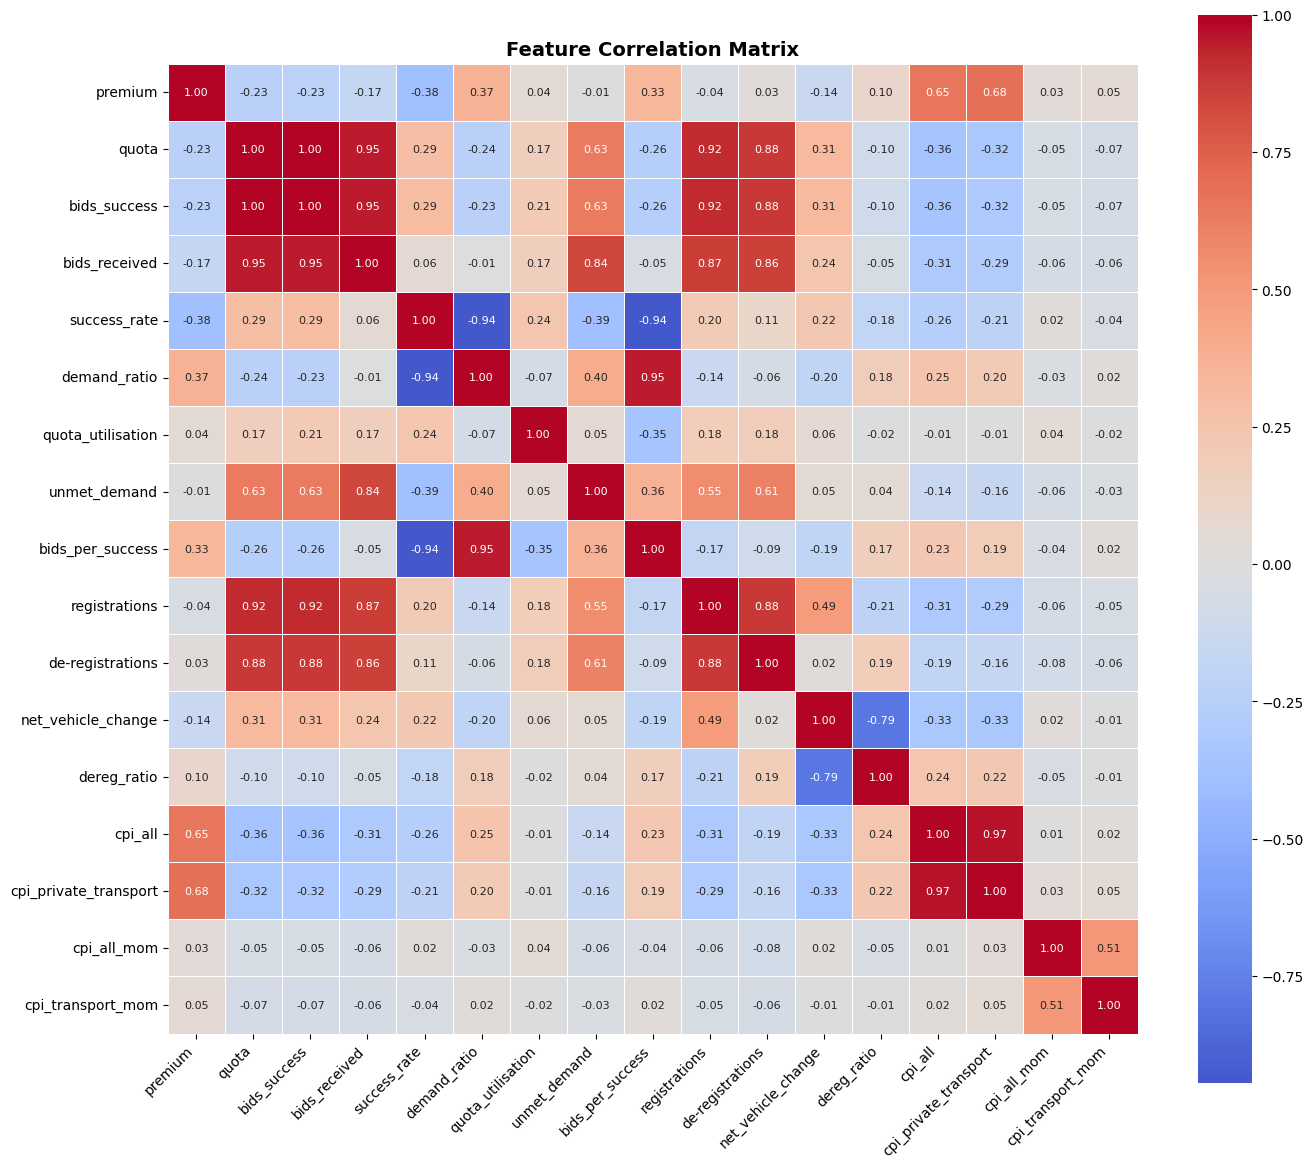


Highly correlated pairs (|r| > 0.85):
  quota & bids_success: r = 1.00
  quota & bids_received: r = 0.95
  quota & registrations: r = 0.92
  quota & de-registrations: r = 0.88
  bids_success & bids_received: r = 0.95
  bids_success & registrations: r = 0.92
  bids_success & de-registrations: r = 0.88
  bids_received & registrations: r = 0.87
  bids_received & de-registrations: r = 0.86
  success_rate & demand_ratio: r = -0.94
  success_rate & bids_per_success: r = -0.94
  demand_ratio & bids_per_success: r = 0.95
  registrations & de-registrations: r = 0.88
  cpi_all & cpi_private_transport: r = 0.97


In [46]:
# Engineer all new features first
df['success_rate'] = df['bids_success'] / df['bids_received']
df['demand_ratio'] = df['bids_received'] / df['quota']
df['quota_utilisation'] = df['bids_success'] / df['quota']
df['unmet_demand'] = df['bids_received'] - df['bids_success']
df['bids_per_success'] = df['bids_received'] / df['bids_success']
df['net_vehicle_change'] = df['registrations'] - df['de-registrations']
df['dereg_ratio'] = df['de-registrations'] / df['registrations']
df['cpi_all_mom'] = df.groupby('vehicle_class')['cpi_all'].pct_change()
df['cpi_transport_mom'] = df.groupby('vehicle_class')['cpi_private_transport'].pct_change()

# Check correlations among all numeric features
feature_cols = [
    'premium', 'quota', 'bids_success', 'bids_received',
    'success_rate', 'demand_ratio', 'quota_utilisation',
    'unmet_demand', 'bids_per_success', 'registrations',
    'de-registrations', 'net_vehicle_change', 'dereg_ratio',
    'cpi_all', 'cpi_private_transport', 'cpi_all_mom', 'cpi_transport_mom'
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (>0.85)
print("\nHighly correlated pairs (|r| > 0.85):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {feature_cols[i]} & {feature_cols[j]}: r = {r:.2f}")

In [47]:
df.columns

Index(['month', 'bidding_no', 'vehicle_class', 'quota', 'bids_success',
       'bids_received', 'premium', 'registrations', 'de-registrations',
       'cpi_all', 'cpi_private_transport', 'success_rate', 'demand_ratio',
       'quota_utilisation', 'unmet_demand', 'bids_per_success',
       'net_vehicle_change', 'dereg_ratio', 'cpi_all_mom',
       'cpi_transport_mom'],
      dtype='str')

In [48]:
df = df.drop(columns=['bids_success', 'bids_per_success', 'cpi_all', 
                       'net_vehicle_change', 'cpi_transport_mom'])

In [49]:
df.columns

Index(['month', 'bidding_no', 'vehicle_class', 'quota', 'bids_received',
       'premium', 'registrations', 'de-registrations', 'cpi_private_transport',
       'success_rate', 'demand_ratio', 'quota_utilisation', 'unmet_demand',
       'dereg_ratio', 'cpi_all_mom'],
      dtype='str')

In [50]:
# Aggregate to monthly level
monthly_df = df.groupby(['month', 'vehicle_class']).agg({
    'quota': 'sum',
    'bids_received': 'sum',
    'premium': 'mean',
    'success_rate': 'mean',
    'demand_ratio': 'mean',
    'quota_utilisation': 'mean',
    'unmet_demand': 'sum',
    'registrations': 'first',
    'de-registrations': 'first',
    'dereg_ratio': 'first',
    'cpi_private_transport': 'first',
    'cpi_all_mom': 'first'
}).reset_index()

In [51]:
monthly_df.shape

(1425, 14)

In [52]:
monthly_df.head()

,month,vehicle_class,quota,bids_received,premium,success_rate,demand_ratio,quota_utilisation,unmet_demand,registrations,de-registrations,dereg_ratio,cpi_private_transport,cpi_all_mom
0,2002-04-01,Category A,2259,4374,36600.5,0.523510,1.941373,0.991457,2134,3275,3883,1.185649,NaN,NaN
1,2002-04-01,Category B,1111,2223,40805.0,0.496655,2.000880,0.993728,1119,2021,1910,0.945077,NaN,NaN
2,2002-04-01,Category C,1012,1608,23501.0,0.619592,1.588933,0.984190,612,974,982,1.008214,NaN,NaN
3,2002-04-01,Category D,1677,2403,474.5,0.702598,1.432833,0.997020,731,1445,2414,1.670588,NaN,NaN
4,2002-04-01,Category E,1436,3204,41522.0,0.443161,2.250473,0.961947,1820,<NA>,<NA>,<NA>,NaN,NaN


In [53]:
# Sort first
monthly_df = monthly_df.sort_values(['vehicle_class', 'month'])

# 3-month and 6-month lagged moving averages of premium (per vehicle class)
monthly_df['premium_ma3'] = monthly_df.groupby('vehicle_class')['premium'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
monthly_df['premium_ma6'] = monthly_df.groupby('vehicle_class')['premium'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

# 3-month lagged moving average of demand ratio
monthly_df['demand_ratio_ma3'] = monthly_df.groupby('vehicle_class')['demand_ratio'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

# 3-month lagged moving average of registrations
monthly_df['registrations_ma3'] = monthly_df.groupby('vehicle_class')['registrations'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

monthly_df = monthly_df.reset_index(drop=True)


In [54]:
monthly_df.to_csv("final_dataset.csv", index=True)